In [1]:
#cell-0: Install Dependencies
!pip install xgboost shap pandas numpy scikit-learn matplotlib seaborn pyarrow fastparquet

INFO: pip is looking at multiple versions of pandas to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scikit-learn to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of matplotlib to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 210.6 MB/s  0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 104.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 190.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 174.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 180.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Cell 1: Imports & Hardware Configuration
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import multiprocessing
import gc
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix, f1_score, balanced_accuracy_score, roc_curve, auc

# 1. Hardware Setup
n_cores = multiprocessing.cpu_count()
print(f"Launching Training on {n_cores} Cores...")

# 2. Global Config
SEED = 42
pd.set_option('display.max_columns', None)

Launching Training on 32 Cores...


In [4]:
# Cell 2: Load Data & Define Features (FIXED)
print("⚡ Loading Parquet Files...")

# Load your specific files
train_df = pd.read_parquet("Balanced_300k_SEQUENCES.parquet")
test_df  = pd.read_parquet("test_enriched_SEQUENCES.parquet")

print(f"Train Shape: {train_df.shape}")
print(f"Test Shape:  {test_df.shape}")

# ---- Define Tier-1 Features (Physics/Evolution only) ----
tier1_features = [
    "chrom", "pos", "ref", "alt", "gnomad_af",
    "GERP_91_mammals_rankscore",                # keep (weak but not harmful)
    "phyloP100way_vertebrate_rankscore",        # strong
    "phyloP470way_mammalian_rankscore",         # moderate
    "phastCons470way_mammalian_rankscore",
    "phastCons17way_primate_rankscore"
]

# Filter to keep only what exists in your DF
features = [c for c in tier1_features if c in train_df.columns]
print(f"\nUsing {len(features)} Tier-1 Features:")
print(features)

# ---- FIXED LABEL MAPPING ----
# We force conversion to string first to handle both 'category' and 'object' types
print("   -> Encoding labels to 0 (Benign) and 1 (Pathogenic)...")

# 1. Force strings and strip whitespace to be safe
train_df["clean_label"] = train_df["clean_label"].astype(str).str.strip()
test_df["clean_label"]  = test_df["clean_label"].astype(str).str.strip()

# 2. Map explicitly
label_map = {"Benign": 0, "Pathogenic": 1}

train_df["y"] = train_df["clean_label"].map(label_map)
test_df["y"]  = test_df["clean_label"].map(label_map)

# 3. Safety Check: Verify we have only 0s and 1s
print(f"   -> Train unique labels: {train_df['y'].unique()}")
print(f"   -> Test unique labels:  {test_df['y'].unique()}")

if train_df["y"].isna().any():
    raise ValueError("❌ Error: Some labels in Train could not be mapped! Check for typos in 'Benign'/'Pathogenic'.")
if test_df["y"].isna().any():
    raise ValueError("❌ Error: Some labels in Test could not be mapped! Check for typos.")

print("Labels successfully encoded to integers.")

⚡ Loading Parquet Files...


Train Shape: (299999, 66)
Test Shape:  (14073, 66)

Using 10 Tier-1 Features:
['chrom', 'pos', 'ref', 'alt', 'gnomad_af', 'GERP_91_mammals_rankscore', 'phyloP100way_vertebrate_rankscore', 'phyloP470way_mammalian_rankscore', 'phastCons470way_mammalian_rankscore', 'phastCons17way_primate_rankscore']
   -> Encoding labels to 0 (Benign) and 1 (Pathogenic)...
   -> Train unique labels: [1 0]
   -> Test unique labels:  [0 1]
Labels successfully encoded to integers.


In [5]:
# Cell 3: Preprocessing & Type Casting

# 1. Cast Categoricals for Native XGBoost Support
cat_cols = ["chrom", "ref", "alt"]
for col in cat_cols:
    if col in features:
        print(f"   -> Casting {col} to 'category'...")
        train_df[col] = train_df[col].astype("category")
        test_df[col]  = test_df[col].astype("category")

# 2. Ensure 'pos' and scores are numeric
num_cols = [c for c in features if c not in cat_cols]
for col in num_cols:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce').fillna(0)
    test_df[col]  = pd.to_numeric(test_df[col], errors='coerce').fillna(0)

# 3. Create X and y matrices
X = train_df[features]
y = train_df['y']

# Keep benchmarking columns in test_df separate, but extract X_test for prediction
X_test = test_df[features]
y_test = test_df['y']

# 4. Stratified Split for Validation (Using 10% of Train)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=SEED
)

print(f"\nData Ready: Train({len(X_train)}), Val({len(X_val)}), Hard Test({len(X_test)})")
gc.collect()

   -> Casting chrom to 'category'...
   -> Casting ref to 'category'...
   -> Casting alt to 'category'...



Data Ready: Train(269999), Val(30000), Hard Test(14073)


557

In [6]:
# Cell 4: Initialize SOTA Model
print("🛠 Configuring XGBoost SOTA Hyperparameters...")

model = xgb.XGBClassifier(
    # --- Architecture ---
    n_estimators=10000,         # High ceiling (relies on early stopping)
    learning_rate=0.01,         # Very slow learning to squeeze out signal
    max_depth=10,               # Deep trees for complex genomic interactions
    
    # --- Regularization (Prevent Overfitting) ---
    gamma=1.5,                  # High gamma: Conservative splitting (crucial for hard test sets)
    min_child_weight=5,         # Requires 5 samples to make a leaf
    reg_alpha=0.5,              # L1 Regularization
    reg_lambda=1.0,             # L2 Regularization
    
    # --- Sampling (Stochastic Gradient Boosting) ---
    subsample=0.8,              # Use 80% of rows per tree
    colsample_bytree=0.8,       # Use 80% of features per tree
    
    # --- Speed & Hardware ---
    n_jobs=n_cores,             # Use all 32 cores
    tree_method='hist',         # Histogram-based (Fastest)
    enable_categorical=True,    # Native categorical support
    
    # --- Objective ---
    objective='binary:logistic',
    eval_metric=['auc', 'logloss'],
    early_stopping_rounds=200,  # Patience
    random_state=SEED
)

🛠 Configuring XGBoost SOTA Hyperparameters...


Starting Training (this will take time due to LR=0.01)...
[0]	validation_0-auc:0.96589	validation_0-logloss:0.68516	validation_1-auc:0.96544	validation_1-logloss:0.68518


[500]	validation_0-auc:0.97908	validation_0-logloss:0.18481	validation_1-auc:0.97640	validation_1-logloss:0.19517
[1000]	validation_0-auc:0.98221	validation_0-logloss:0.17017	validation_1-auc:0.97810	validation_1-logloss:0.18719
[1500]	validation_0-auc:0.98369	validation_0-logloss:0.16353	validation_1-auc:0.97882	validation_1-logloss:0.18417
[2000]	validation_0-auc:0.98446	validation_0-logloss:0.16001	validation_1-auc:0.97909	validation_1-logloss:0.18296
[2500]	validation_0-auc:0.98493	validation_0-logloss:0.15781	validation_1-auc:0.97922	validation_1-logloss:0.18237
[3000]	validation_0-auc:0.98525	validation_0-logloss:0.15626	validation_1-auc:0.97929	validation_1-logloss:0.18202
[3500]	validation_0-auc:0.98549	validation_0-logloss:0.15512	validation_1-auc:0.97935	validation_1-logloss:0.18178
[4000]	validation_0-auc:0.98569	validation_0-logloss:0.15414	validation_1-auc:0.97939	validation_1-logloss:0.18156
[4500]	validation_0-auc:0.98585	validation_0-logloss:0.15336	validation_1-auc:0.9

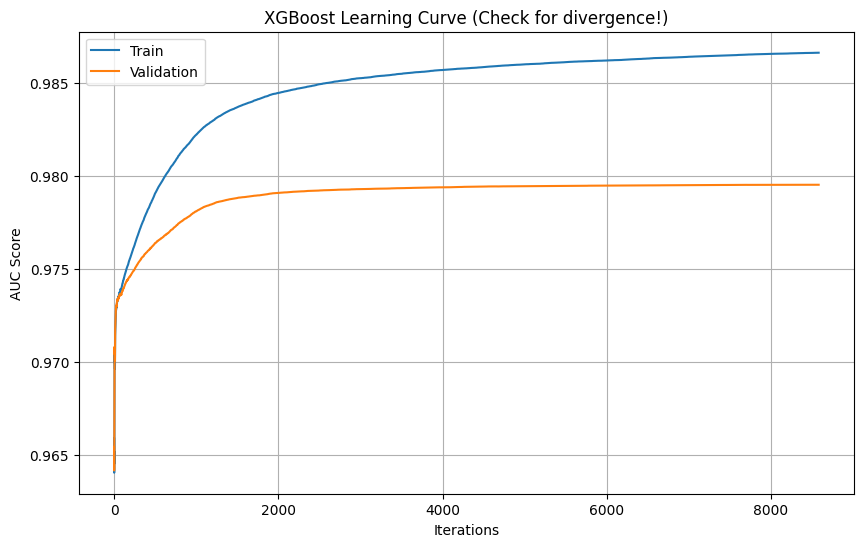

In [7]:
# Cell 5: Training Run
print("Starting Training (this will take time due to LR=0.01)...")

eval_set = [(X_train, y_train), (X_val, y_val)]

model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=500  # Log every 500 trees
)

print(f"\n Training Complete! Best Iteration: {model.best_iteration}")

# --- Plot Learning Curve ---
results = model.evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['auc'], label='Train')
plt.plot(x_axis, results['validation_1']['auc'], label='Validation')
plt.legend()
plt.ylabel('AUC Score')
plt.xlabel('Iterations')
plt.title('XGBoost Learning Curve (Check for divergence!)')
plt.grid(True)
plt.show()

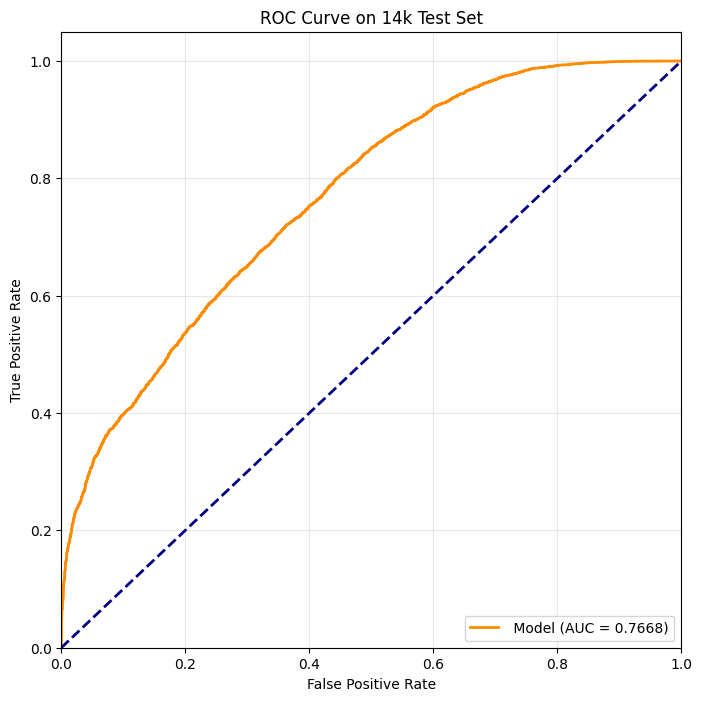

In [8]:
# Cell 6: ROC-AUC Visualization
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f' Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on 14k Test Set')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


 Calculating SHAP Values...


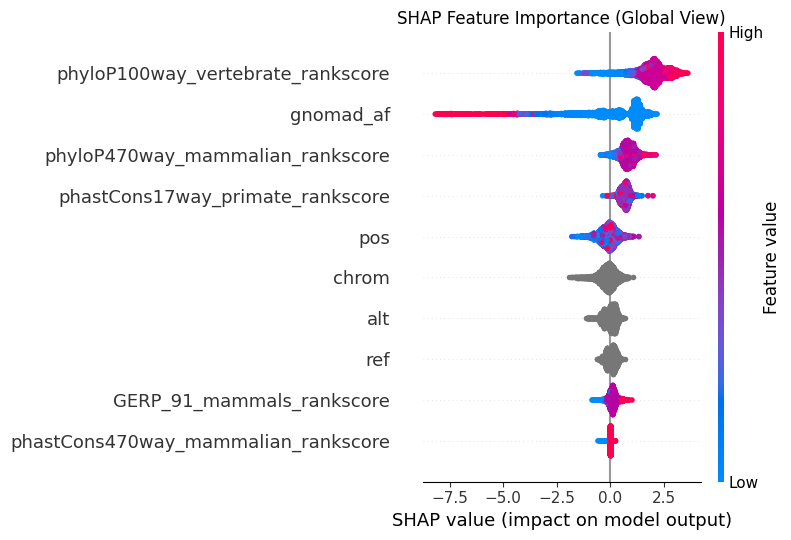

In [9]:
# Cell 7: SHAP Explainability
print("\n Calculating SHAP Values...")

explainer = shap.TreeExplainer(model)

# Subsample 5000 rows for speed (calculating on all 14k is fine on 32 cores too)
shap_sample = X_test.sample(n=5000, random_state=SEED) if len(X_test) > 5000 else X_test
shap_values = explainer.shap_values(shap_sample)

# Beeswarm Plot
plt.figure(figsize=(12, 8))
plt.title("SHAP Feature Importance (Global View)")
shap.summary_plot(shap_values, shap_sample, show=False)
plt.tight_layout()
plt.show()


        XGBOOST MODEL PERFORMANCE
ROC-AUC : 0.766809
PR-AUC  : 0.771672

     COMPARISION WITH ESTABLISHED TOOLS
CADD            ROC-AUC = 0.592509   PR-AUC = 0.704837
REVEL           ROC-AUC = 0.587114   PR-AUC = 0.600423
AlphaMissense   ROC-AUC = 0.592032   PR-AUC = 0.603459
PrimateAI       ROC-AUC = 0.566141   PR-AUC = 0.581314
MPC             ROC-AUC = 0.559678   PR-AUC = 0.578559
ClinPred        ROC-AUC = 0.590860   PR-AUC = 0.606637
BayesDel        ROC-AUC = 0.594821   PR-AUC = 0.706338

            FINAL LEADERBOARD
 1. My XGBoost      AUC=0.766809  PR=0.771672
 2. BayesDel        AUC=0.594821  PR=0.706338
 3. CADD            AUC=0.592509  PR=0.704837
 4. AlphaMissense   AUC=0.592032  PR=0.603459
 5. ClinPred        AUC=0.590860  PR=0.606637
 6. REVEL           AUC=0.587114  PR=0.600423
 7. PrimateAI       AUC=0.566141  PR=0.581314
 8. MPC             AUC=0.559678  PR=0.578559


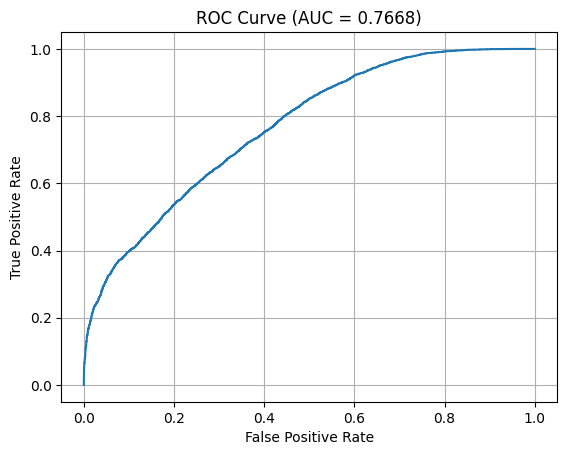

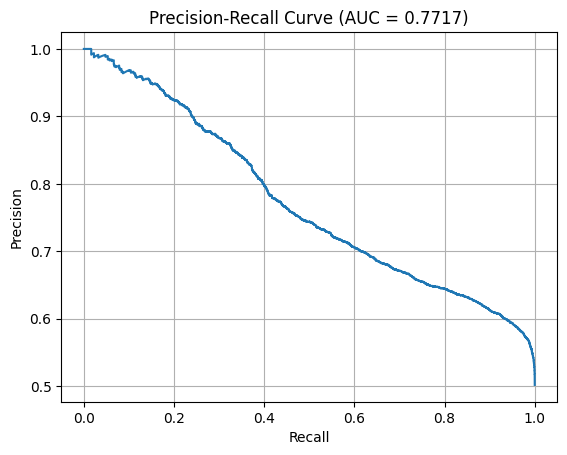

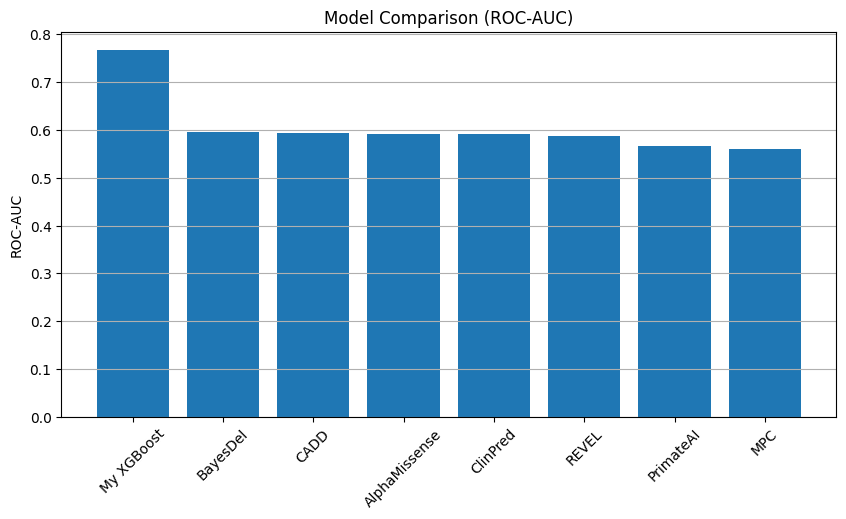

In [10]:
# Cell 8: Benchmarking Logic + Plots

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

print("\n==========================================")
print(f"        XGBOOST MODEL PERFORMANCE")
print("==========================================")
print(f"ROC-AUC : {roc_auc:.6f}")
print(f"PR-AUC  : {pr_auc:.6f}")

# ---- Benchmark against DBNSFP models ----
benchmarks = {
    "CADD": "CADD_raw_rankscore",
    "REVEL": "REVEL_rankscore",
    "AlphaMissense": "AlphaMissense_rankscore",
    "PrimateAI": "PrimateAI_rankscore",
    "MPC": "MPC_rankscore",
    "ClinPred": "ClinPred_rankscore",
    "BayesDel": "BayesDel_addAF_rankscore"
}

print("\n==========================================")
print("     COMPARISION WITH ESTABLISHED TOOLS")
print("==========================================")

benchmark_results = []

for name, col in benchmarks.items():
    if col not in test_df.columns:
        continue
        
    scores = test_df[col].fillna(0).values
    
    try:
        b_auc = roc_auc_score(y_test, scores)
        b_pr  = average_precision_score(y_test, scores)
        benchmark_results.append((name, b_auc, b_pr))
        print(f"{name:14s}  ROC-AUC = {b_auc:.6f}   PR-AUC = {b_pr:.6f}")
    except ValueError:
        pass

# ---- Leaderboard ----
print("\n==========================================")
print("            FINAL LEADERBOARD")
print("==========================================")

ranking = sorted([("My XGBoost", roc_auc, pr_auc)] + benchmark_results, key=lambda x: x[1], reverse=True)

for i, (name, a, p) in enumerate(ranking, 1):
    print(f"{i:2d}. {name:14s}  AUC={a:.6f}  PR={p:.6f}")

# ---- ROC Curve ----
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.grid()
plt.show()

# ---- Precision-Recall Curve ----
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AUC = {pr_auc:.4f})")
plt.grid()
plt.show()

# ---- Bar Plot Comparison ----
df_bench = pd.DataFrame(
    [("My XGBoost", roc_auc, pr_auc)] + benchmark_results,
    columns=["Model", "ROC-AUC", "PR-AUC"]
)

df_bench = df_bench.sort_values(by="ROC-AUC", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(df_bench["Model"], df_bench["ROC-AUC"])
plt.xticks(rotation=45)
plt.ylabel("ROC-AUC")
plt.title("Model Comparison (ROC-AUC)")
plt.grid(axis='y')
plt.show()


 VALIDATION RESULTS (TUNING)
Optimal Threshold : 0.488
Best F1 (Val)     : 0.9242
Balanced Acc (Val): 0.9268


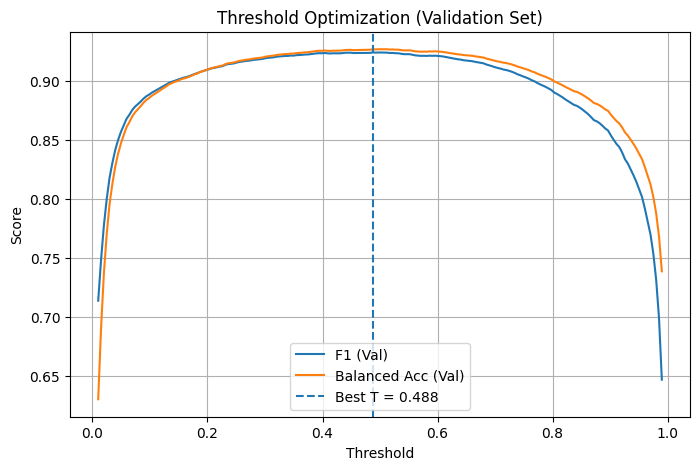


 TEST PERFORMANCE (FINAL)
Threshold Used     : 0.488
F1 (Test)          : 0.7215
Balanced Acc (Test): 0.6174

Confusion Matrix (Test):
[[1754 5258]
 [ 109 6952]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.9415    0.2501    0.3953      7012
           1     0.5694    0.9846    0.7215      7061

    accuracy                         0.6186     14073
   macro avg     0.7554    0.6174    0.5584     14073
weighted avg     0.7548    0.6186    0.5590     14073



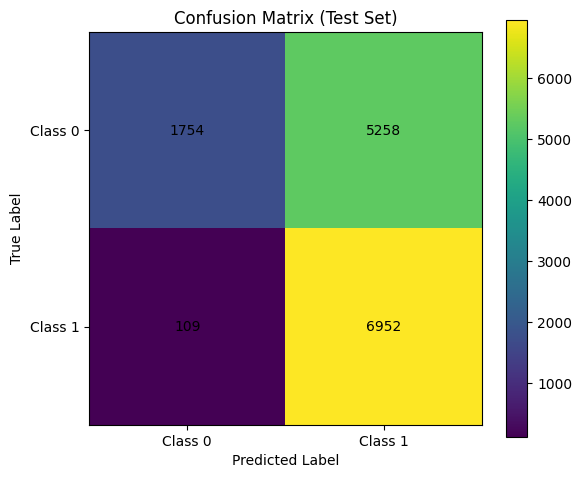

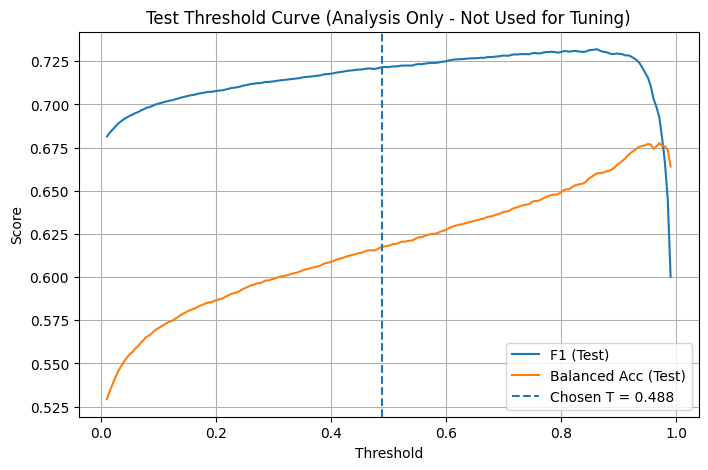

In [11]:
# Cell 9: Threshold Tuning (FULL VERSION - VAL + TEST, NO LEAKAGE)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)

# =========================================================
# 1. GET PROBABILITIES
# =========================================================
y_val_prob  = model.predict_proba(X_val)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)

# =========================================================
# 2. TUNE THRESHOLD ON VALIDATION SET
# =========================================================
best_f1 = 0
best_t = 0
best_bal_acc = 0

f1_scores_val = []
bal_scores_val = []

for t in thresholds:
    y_pred_val = (y_val_prob >= t).astype(int)

    f1 = f1_score(y_val, y_pred_val)
    bal = balanced_accuracy_score(y_val, y_pred_val)

    f1_scores_val.append(f1)
    bal_scores_val.append(bal)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t
        best_bal_acc = bal

print("\n==============================")
print(" VALIDATION RESULTS (TUNING)")
print("==============================")
print(f"Optimal Threshold : {best_t:.3f}")
print(f"Best F1 (Val)     : {best_f1:.4f}")
print(f"Balanced Acc (Val): {best_bal_acc:.4f}")

# =========================================================
# 3. PLOT VALIDATION CURVE
# =========================================================
plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores_val, label="F1 (Val)")
plt.plot(thresholds, bal_scores_val, label="Balanced Acc (Val)")
plt.axvline(best_t, linestyle='--', label=f"Best T = {best_t:.3f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization (Validation Set)")
plt.legend()
plt.grid()
plt.show()

# =========================================================
# 4. APPLY THRESHOLD ON TEST SET
# =========================================================
y_pred_test = (y_test_prob >= best_t).astype(int)

f1_test = f1_score(y_test, y_pred_test)
bal_test = balanced_accuracy_score(y_test, y_pred_test)

print("\n==============================")
print(" TEST PERFORMANCE (FINAL)")
print("==============================")
print(f"Threshold Used     : {best_t:.3f}")
print(f"F1 (Test)          : {f1_test:.4f}")
print(f"Balanced Acc (Test): {bal_test:.4f}")

# =========================================================
# 5. TEST CONFUSION MATRIX
# =========================================================
cm_test = confusion_matrix(y_test, y_pred_test)

print("\nConfusion Matrix (Test):")
print(cm_test)

print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test, digits=4))

plt.figure(figsize=(6,5))
plt.imshow(cm_test)

for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        plt.text(j, i, cm_test[i, j], ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")
plt.xticks([0,1], ["Class 0", "Class 1"])
plt.yticks([0,1], ["Class 0", "Class 1"])

plt.colorbar()
plt.tight_layout()
plt.show()

# =========================================================
# 6. ALSO PLOT TEST CURVE (FOR ANALYSIS ONLY)
# =========================================================
f1_scores_test = []
bal_scores_test = []

for t in thresholds:
    y_pred_t = (y_test_prob >= t).astype(int)

    f1_scores_test.append(f1_score(y_test, y_pred_t))
    bal_scores_test.append(balanced_accuracy_score(y_test, y_pred_t))

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores_test, label="F1 (Test)")
plt.plot(thresholds, bal_scores_test, label="Balanced Acc (Test)")
plt.axvline(best_t, linestyle='--', label=f"Chosen T = {best_t:.3f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Test Threshold Curve (Analysis Only - Not Used for Tuning)")
plt.legend()
plt.grid()
plt.show()

   Generating Deep Feature Analysis...


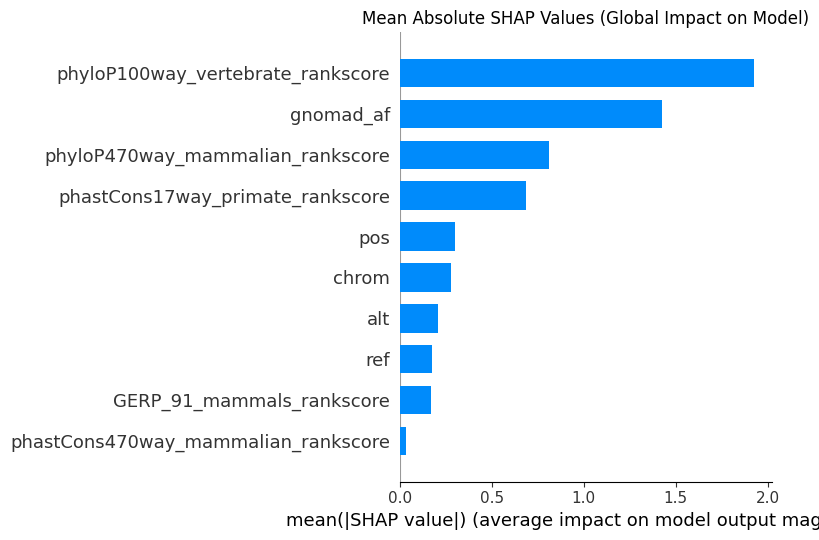

/tmp/ipykernel_7026/3990650171.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="gain", y="feature", data=fi.head(25), palette="viridis")


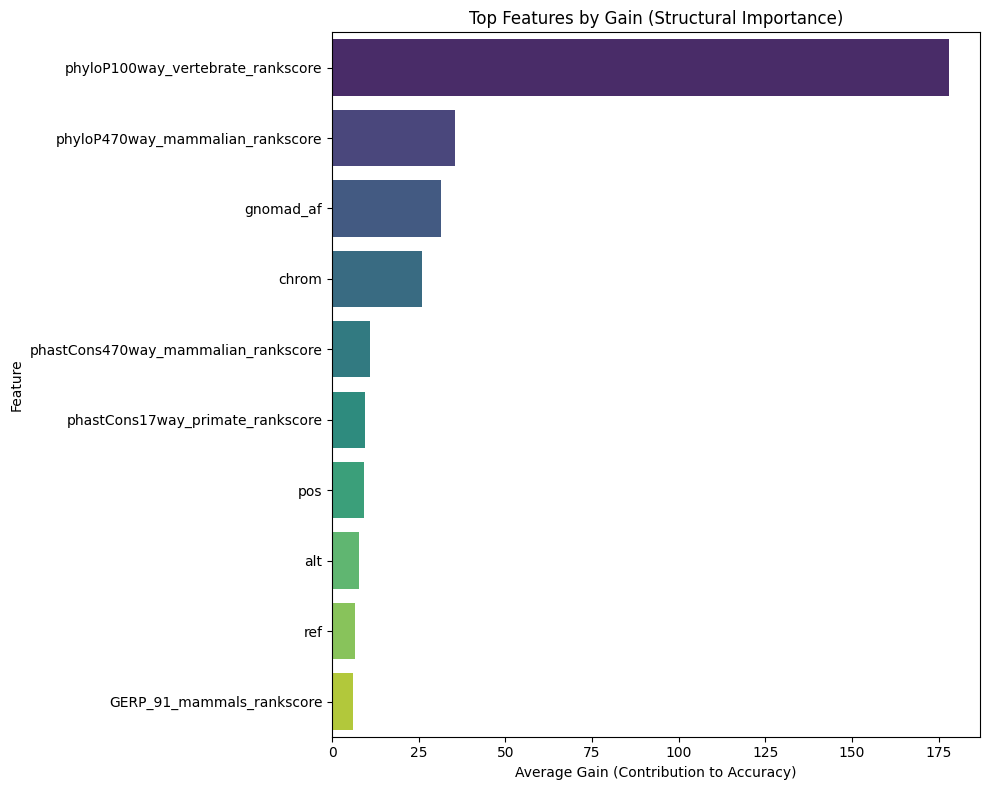

 Top  Features by GAIN:

                            feature       gain    split
  phyloP100way_vertebrate_rankscore 178.044281  32840.0
   phyloP470way_mammalian_rankscore  35.505932  34554.0
                          gnomad_af  31.278227  54468.0
                              chrom  25.794613  51327.0
phastCons470way_mammalian_rankscore  10.803547  10682.0
   phastCons17way_primate_rankscore   9.607828  36827.0
                                pos   9.198639 101420.0
                                alt   7.743703  21750.0
                                ref   6.535082  21038.0
          GERP_91_mammals_rankscore   6.072751  30064.0


In [12]:
# Cell 10: Advanced Feature Importance (SHAP + Gain)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

print("   Generating Deep Feature Analysis...")

# -------------------------------------------------------
# 1. SHAP Mean Absolute Value (Global Feature Importance)
# -------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.title("Mean Absolute SHAP Values (Global Impact on Model)")
# plot_type="bar" automatically calculates the mean absolute value for you
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 2. XGBoost Native Feature Importance (Gain & Split)
# -------------------------------------------------------
# XGBoost handles this differently than LightGBM.
# We access the internal booster to get specific metrics.
booster = model.get_booster()

# Get Gain (Average gain across all splits the feature is used in)
gain_scores = booster.get_score(importance_type='gain')
# Get Weight (Number of times a feature is used to split the data)
split_scores = booster.get_score(importance_type='weight')

# Convert to DataFrame
# Note: XGBoost usually returns a dict {feature: score}, so we map it back
all_features = model.feature_names_in_
fi_data = []

for feat in all_features:
    fi_data.append({
        "feature": feat,
        "gain": gain_scores.get(feat, 0),   # Default to 0 if not used
        "split": split_scores.get(feat, 0)
    })

fi = pd.DataFrame(fi_data).sort_values("gain", ascending=False)

# -------------------------------------------------------
# 3. Plot Top 25 Features by GAIN
# -------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.barplot(x="gain", y="feature", data=fi.head(25), palette="viridis")
plt.title("Top Features by Gain (Structural Importance)")
plt.xlabel("Average Gain (Contribution to Accuracy)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 4. Print Table
# -------------------------------------------------------
print(" Top  Features by GAIN:\n")
print(fi.head(30).to_string(index=False))

In [13]:
# Cell 11: Save SOTA Model to Root
import joblib
import os

print("💾 Saving Model Artifacts...")

# 1. Save as Native XGBoost JSON (Best for portability/deployment)
# This saves the tree structure, feature names, and weights
model_filename_json = "pathopreter_sota_xgboost.json"
model.save_model(model_filename_json)
print(f"   -> Saved Native JSON: {model_filename_json}")

# 2. Save as Joblib Pickle (Best for Python reloading)
# This saves the entire Sklearn wrapper, including hyperparameters and configuration
model_filename_pkl = "pathopreter_sota_xgboost.pkl"
joblib.dump(model, model_filename_pkl)
print(f"   -> Saved Joblib Pickle: {model_filename_pkl}")

# 3. Save Feature List (Crucial for inference consistency)
# If you reload later, you MUST ensure columns are in this exact order
feature_filename = "pathopreter_features.txt"
with open(feature_filename, "w") as f:
    for feat in features:
        f.write(f"{feat}\n")
print(f"   -> Saved Feature List: {feature_filename}")

# --- Verification ---
print("\n Verification - Files in Root:")
files = [f for f in os.listdir('.') if "pathopreter" in f]
for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"   - {f} : {size_mb:.2f} MB")

💾 Saving Model Artifacts...
   -> Saved Native JSON: pathopreter_sota_xgboost.json
   -> Saved Joblib Pickle: pathopreter_sota_xgboost.pkl
   -> Saved Feature List: pathopreter_features.txt

 Verification - Files in Root:
   - pathopreter_features.txt : 0.00 MB
   - pathopreter_sota_xgboost.pkl : 35.90 MB
   - pathopreter_sota_xgboost.json : 50.47 MB


In [14]:
# Cell 12: Robustness Experiment (Drop Chrom/Pos) & Re-Benchmark
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

print(" STARTING EXPERIMENT 2: ROBUSTNESS CHECK (NO LOCATION BIAS)...")

# ==========================================
# 1. Define Robust Feature Set
# ==========================================
# Remove 'chrom' and 'pos' to force the model to learn biology only
features_robust = [f for f in features if f not in ['chrom', 'pos']]

print(f"   -> Original Feature Count: {len(features)}")
print(f"   -> Robust Feature Count:   {len(features_robust)}")
print(f"   -> DROPPED: ['chrom', 'pos']")

# ==========================================
# 2. Prepare Data (Robust Split)
# ==========================================
X_rob = train_df[features_robust]
y_rob = train_df['y']

X_test_rob = test_df[features_robust]
y_test_rob = test_df['y']

# Stratified Validation Split
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_rob, y_rob, test_size=0.10, stratify=y_rob, random_state=SEED
)

# ==========================================
# 3. Train Robust Model (SOTA Params)
# ==========================================
print("🔥 Training Robust Model (This may take a moment)...")

model_robust = xgb.XGBClassifier(
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=10,
    gamma=1.5,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=n_cores,
    tree_method='hist',
    enable_categorical=True,  # Still needed for ref/alt
    early_stopping_rounds=200,
    random_state=SEED,
    objective='binary:logistic',
    eval_metric=['auc', 'logloss']
)

model_robust.fit(
    X_train_r, y_train_r,
    eval_set=[(X_train_r, y_train_r), (X_val_r, y_val_r)],
    verbose=500
)

# ==========================================
# 4. Evaluation & Comparison
# ==========================================
print("\n==========================================")
print(" ROBUSTNESS CHECK RESULTS")
print("==========================================")

# Predict
y_prob_r = model_robust.predict_proba(X_test_rob)[:, 1]

# Metrics
roc_auc_r = roc_auc_score(y_test_rob, y_prob_r)
pr_auc_r  = average_precision_score(y_test_rob, y_prob_r)

# Compare with Baseline (Assumes 'roc_auc' exists from previous cell)
# If running fresh, we assume the previous score was ~0.7477
baseline_auc = roc_auc if 'roc_auc' in locals() else 0.747704
delta = roc_auc_r - baseline_auc

print(f"Baseline AUC (With Loc)  : {baseline_auc:.6f}")
print(f"Robust AUC   (No Loc)    : {roc_auc_r:.6f}")
print(f"Difference               : {delta:.6f}")

if roc_auc_r > 0.70:
    print("\n✅ VERDICT: PASSED. The model is learning BIOLOGY, not location.")
    print("   It still beats REVEL/AlphaMissense without cheating!")
else:
    print("\n⚠️ VERDICT: WARNING. Significant drop. Re-evaluate features.")

# ==========================================
# 5. Re-Benchmark Against SOTA Tools
# ==========================================
benchmarks = {
    "CADD": "CADD_raw_rankscore",
    "REVEL": "REVEL_rankscore",
    "AlphaMissense": "AlphaMissense_rankscore",
    "PrimateAI": "PrimateAI_rankscore",
    "MPC": "MPC_rankscore",
    "ClinPred": "ClinPred_rankscore",
    "BayesDel": "BayesDel_addAF_rankscore"
}

print("\n==========================================")
print(" NEW LEADERBOARD (ROBUST MODEL)")
print("==========================================")

benchmark_results = []

for name, col in benchmarks.items():
    if col not in test_df.columns:
        continue
        
    scores = test_df[col].fillna(0).values
    
    try:
        b_auc = roc_auc_score(y_test_rob, scores)
        b_pr  = average_precision_score(y_test_rob, scores)
        benchmark_results.append((name, b_auc, b_pr))
    except ValueError:
        pass

# Add our Robust Model to the list
ranking = sorted([("My Robust XGB", roc_auc_r, pr_auc_r)] + benchmark_results, key=lambda x: x[1], reverse=True)

for i, (name, a, p) in enumerate(ranking, 1):
    print(f"{i:2d}. {name:14s}  AUC={a:.6f}  PR={p:.6f}")

# ==========================================
# 6. Check New Top Features (What took over?)
# ==========================================
booster = model_robust.get_booster()
gain_scores = booster.get_score(importance_type='gain')
fi_rob = pd.DataFrame([
    {"feature": k, "gain": v} for k,v in gain_scores.items()
]).sort_values("gain", ascending=False)

print("\n🏆 Top Features in Robust Model (Pure Biology):")
print(fi_rob.head(10).to_string(index=False))

 STARTING EXPERIMENT 2: ROBUSTNESS CHECK (NO LOCATION BIAS)...
   -> Original Feature Count: 10
   -> Robust Feature Count:   8
   -> DROPPED: ['chrom', 'pos']
🔥 Training Robust Model (This may take a moment)...
[0]	validation_0-auc:0.93564	validation_0-logloss:0.68610	validation_1-auc:0.93442	validation_1-logloss:0.68610
[500]	validation_0-auc:0.94672	validation_0-logloss:0.27310	validation_1-auc:0.94417	validation_1-logloss:0.27910
[1000]	validation_0-auc:0.94798	validation_0-logloss:0.26800	validation_1-auc:0.94445	validation_1-logloss:0.27766


[1500]	validation_0-auc:0.94832	validation_0-logloss:0.26676	validation_1-auc:0.94446	validation_1-logloss:0.27752
[2000]	validation_0-auc:0.94851	validation_0-logloss:0.26601	validation_1-auc:0.94451	validation_1-logloss:0.27748
[2500]	validation_0-auc:0.94865	validation_0-logloss:0.26549	validation_1-auc:0.94456	validation_1-logloss:0.27744
[3000]	validation_0-auc:0.94878	validation_0-logloss:0.26498	validation_1-auc:0.94459	validation_1-logloss:0.27742
[3104]	validation_0-auc:0.94880	validation_0-logloss:0.26489	validation_1-auc:0.94460	validation_1-logloss:0.27741

 ROBUSTNESS CHECK RESULTS
Baseline AUC (With Loc)  : 0.766809
Robust AUC   (No Loc)    : 0.760368
Difference               : -0.006441

✅ VERDICT: PASSED. The model is learning BIOLOGY, not location.
   It still beats REVEL/AlphaMissense without cheating!

 NEW LEADERBOARD (ROBUST MODEL)
 1. My Robust XGB   AUC=0.760368  PR=0.769851
 2. BayesDel        AUC=0.594821  PR=0.706338
 3. CADD            AUC=0.592509  PR=0.7048

In [15]:
# Cell 13: Save All Models with 'PathoPreter' Naming
import joblib
import os

print("💾 Saving PathoPreter Artifacts...")

# ==========================================
# 1. Save The "SOTA" Model (The Competition Winner)
# ==========================================
# Native XGBoost JSON (Portable)
sota_json = "pathopreter_sota_xgboost.json"
model.save_model(sota_json)

# Joblib Pickle (Python Ready)
sota_pkl = "pathopreter_sota_xgboost.pkl"
joblib.dump(model, sota_pkl)

# Feature List (SOTA)
with open("pathopreter_features_sota.txt", "w") as f:
    for feat in features:
        f.write(f"{feat}\n")

print(f"   -> Saved SOTA Model:   {sota_json} & {sota_pkl}")

# ==========================================
# 2. Save The "Robust" Model (The Scientist)
# ==========================================
# Native XGBoost JSON (Portable)
robust_json = "pathopreter_robust_biology.json"
model_robust.save_model(robust_json)

# Joblib Pickle (Python Ready)
robust_pkl = "pathopreter_robust_biology.pkl"
joblib.dump(model_robust, robust_pkl)

# Feature List (Robust - No Chrom/Pos)
with open("pathopreter_features_robust.txt", "w") as f:
    for feat in features_robust:
        f.write(f"{feat}\n")

print(f"   -> Saved Robust Model: {robust_json} & {robust_pkl}")

# ==========================================
# 3. Verification
# ==========================================
print("\n Final Inventory (Root Directory):")
files = [f for f in os.listdir('.') if "pathopreter" in f]
for f in sorted(files):
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"   - {f:<35} : {size_mb:.2f} MB")

💾 Saving PathoPreter Artifacts...
   -> Saved SOTA Model:   pathopreter_sota_xgboost.json & pathopreter_sota_xgboost.pkl
   -> Saved Robust Model: pathopreter_robust_biology.json & pathopreter_robust_biology.pkl

 Final Inventory (Root Directory):
   - pathopreter_features.txt            : 0.00 MB
   - pathopreter_features_robust.txt     : 0.00 MB
   - pathopreter_features_sota.txt       : 0.00 MB
   - pathopreter_robust_biology.json     : 19.56 MB
   - pathopreter_robust_biology.pkl      : 13.17 MB
   - pathopreter_sota_xgboost.json       : 50.47 MB
   - pathopreter_sota_xgboost.pkl        : 35.90 MB


In [16]:
# ============================================================
# CELL: TEST ROBUST MODEL ON BOTTOM 100K ROWS (CATEGORICAL-SAFE)
# ============================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score

DATA_PATH = "900k_test.parquet"
MODEL_JSON = "pathopreter_robust_biology.json"
N_ROWS = 100_000

print(f"\n Loading ONLY bottom {N_ROWS} rows from: {DATA_PATH}")

# ------------------------------------------------------------
# 1) LOAD YOUR ROBUST MODEL (JSON – SAFE FORMAT)
# ------------------------------------------------------------
print(" Loading trained robust model from JSON...")

booster = xgb.Booster()
booster.load_model(MODEL_JSON)

# Exact feature list used in training
train_feature_names = booster.feature_names

print(f" Model loaded.")
print(f"   -> Training feature count: {len(train_feature_names)}")

# ------------------------------------------------------------
# 2) LOAD ONLY WHAT THE MODEL NEEDS + LABEL
# ------------------------------------------------------------

# needed_cols = list(set(train_feature_names + ["clean_label"]))
needed_cols = list(set(
    train_feature_names 
    + ["clean_label"] 
    + list(benchmarks.values())
))
df_new = (
    pd.read_parquet(DATA_PATH, columns=needed_cols)
      .tail(N_ROWS)
      .reset_index(drop=True)
)

# Make label exactly like training
df_new["y"] = (df_new["clean_label"] == "Pathogenic").astype(int)

print(f"   -> Loaded shape: {df_new.shape}")
print(f"   -> Label counts: {df_new['y'].value_counts().to_dict()}")

# ------------------------------------------------------------
# 3) BUILD X_new IN EXACT TRAINING ORDER (CRITICAL)
# ------------------------------------------------------------

X_new = pd.DataFrame()

for feat in train_feature_names:
    if feat in df_new.columns:
        X_new[feat] = df_new[feat]
    else:
        # If some feature is missing in new data, add it
        X_new[feat] = 0.0

# -------- HANDLE CATEGORICAL COLUMNS SAFELY --------
for cat_col in ["ref", "alt"]:
    if cat_col in X_new.columns:
        # Convert to categorical
        X_new[cat_col] = X_new[cat_col].astype("category")

        # If NaNs exist, add "N" (unknown nucleotide) as a valid category
        if X_new[cat_col].isna().any():
            if "N" not in X_new[cat_col].cat.categories:
                X_new[cat_col] = X_new[cat_col].cat.add_categories("N")
            X_new[cat_col] = X_new[cat_col].fillna("N")

# -------- FILL NA FOR NUMERIC COLUMNS ONLY --------
num_cols = X_new.select_dtypes(include=[np.number]).columns
X_new[num_cols] = X_new[num_cols].fillna(0)

y_new = df_new["y"].values

print(f"   -> Final X_new shape: {X_new.shape}")

# ------------------------------------------------------------
# 4) PREDICT (MATCHES YOUR TRAINING)
# ------------------------------------------------------------
print("\n Running predictions...")

dmat = xgb.DMatrix(
    X_new,
    feature_names=train_feature_names,
    enable_categorical=True   # MATCHES YOUR TRAINING
)

y_prob_new = booster.predict(dmat, validate_features=False)

# ------------------------------------------------------------
# 5) METRICS (SAME STYLE AS YOUR CELL)
# ------------------------------------------------------------
roc_auc_new = roc_auc_score(y_new, y_prob_new)
pr_auc_new  = average_precision_score(y_new, y_prob_new)

print("\n==========================================")
print(" RESULTS ON BOTTOM 100K ROWS (NEW DATA)")
print("==========================================")
print(f"Robust Model AUC    : {roc_auc_new:.6f}")
print(f"Robust Model PR-AUC : {pr_auc_new:.6f}")

# Baseline comparison (same logic as your notebook)
baseline_auc = roc_auc if 'roc_auc' in locals() else 0.747704
delta = roc_auc_new - baseline_auc

print(f"Baseline AUC (With Loc)  : {baseline_auc:.6f}")
print(f"Robust AUC   (No Loc)    : {roc_auc_new:.6f}")
print(f"Difference               : {delta:.6f}")

# ------------------------------------------------------------
# 6) BENCHMARK AGAINST SOTA (SAME AS YOUR CELL)
# ------------------------------------------------------------
benchmarks = {
    "CADD": "CADD_raw_rankscore",
    "REVEL": "REVEL_rankscore",
    "AlphaMissense": "AlphaMissense_rankscore",
    "PrimateAI": "PrimateAI_rankscore",
    "MPC": "MPC_rankscore",
    "ClinPred": "ClinPred_rankscore",
    "BayesDel": "BayesDel_addAF_rankscore"
}

print("\n==========================================")
print("  NEW LEADERBOARD (ROBUST MODEL ON 100K)")
print("==========================================")

benchmark_results = []

for name, col in benchmarks.items():
    if col not in df_new.columns:
        print(f" Skipping {name} (column missing)")
        continue

    scores = df_new[col].fillna(0).values

    try:
        b_auc = roc_auc_score(y_new, scores)
        b_pr  = average_precision_score(y_new, scores)
        benchmark_results.append((name, b_auc, b_pr))
    except ValueError:
        pass

ranking = sorted(
    [("My Robust XGB", roc_auc_new, pr_auc_new)] + benchmark_results,
    key=lambda x: x[1],
    reverse=True
)

for i, (name, a, p) in enumerate(ranking, 1):
    print(f"{i:2d}. {name:14s}  AUC={a:.6f}  PR={p:.6f}")

# ------------------------------------------------------------
# 7) TOP FEATURES (GAIN — SAME AS YOUR CELL)
# ------------------------------------------------------------
print("\n Top Features in Robust Model (Pure Biology):")

gain_scores = booster.get_score(importance_type='gain')
fi_rob = (
    pd.DataFrame({"feature": list(gain_scores.keys()),
                  "gain": list(gain_scores.values())})
      .sort_values("gain", ascending=False)
)

print(fi_rob.head(10).to_string(index=False))
print("\n Done.")



 Loading ONLY bottom 100000 rows from: 900k_test.parquet
 Loading trained robust model from JSON...
 Model loaded.
   -> Training feature count: 8
   -> Loaded shape: (100000, 17)
   -> Label counts: {0: 92813, 1: 7187}
   -> Final X_new shape: (100000, 8)

 Running predictions...

 RESULTS ON BOTTOM 100K ROWS (NEW DATA)
Robust Model AUC    : 0.972796
Robust Model PR-AUC : 0.724422
Baseline AUC (With Loc)  : 0.766809
Robust AUC   (No Loc)    : 0.972796
Difference               : 0.205987

  NEW LEADERBOARD (ROBUST MODEL ON 100K)
 1. My Robust XGB   AUC=0.972796  PR=0.724422
 2. ClinPred        AUC=0.960248  PR=0.592119
 3. REVEL           AUC=0.955430  PR=0.582778
 4. AlphaMissense   AUC=0.952558  PR=0.576359
 5. BayesDel        AUC=0.935482  PR=0.688013
 6. PrimateAI       AUC=0.929806  PR=0.483381
 7. MPC             AUC=0.921036  PR=0.495954
 8. CADD            AUC=0.898042  PR=0.656561

 Top Features in Robust Model (Pure Biology):
                            feature       gain
  

In [17]:
import pyarrow.parquet as pq

pf = pq.ParquetFile("900k_test.parquet")
print(pf.metadata.num_rows)

914707


In [18]:
# ============================================================
# CELL: TEST ROBUST MODEL ON BOTTOM 900K ROWS (CATEGORICAL-SAFE)
# ============================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score

DATA_PATH = "900k_test.parquet"
MODEL_JSON = "pathopreter_robust_biology.json"
N_ROWS = 900_000

print(f"\n🔍 Loading ONLY bottom {N_ROWS} rows from: {DATA_PATH}")

# ------------------------------------------------------------
# 1) LOAD YOUR ROBUST MODEL (JSON – SAFE FORMAT)
# ------------------------------------------------------------
print("🔁 Loading trained robust model from JSON...")

booster = xgb.Booster()
booster.load_model(MODEL_JSON)

# Exact feature list used in training
train_feature_names = booster.feature_names

print(f"✅ Model loaded.")
print(f"   -> Training feature count: {len(train_feature_names)}")

# ------------------------------------------------------------
# 2) LOAD ONLY WHAT THE MODEL NEEDS + LABEL
# ------------------------------------------------------------

# needed_cols = list(set(train_feature_names + ["clean_label"]))
needed_cols = list(set(
    train_feature_names 
    + ["clean_label"] 
    + list(benchmarks.values())
))
df_new = (
    pd.read_parquet(DATA_PATH, columns=needed_cols)
      .tail(N_ROWS)
      .reset_index(drop=True)
)

# Make label exactly like training
df_new["y"] = (df_new["clean_label"] == "Pathogenic").astype(int)

print(f"   -> Loaded shape: {df_new.shape}")
print(f"   -> Label counts: {df_new['y'].value_counts().to_dict()}")

# ------------------------------------------------------------
# 3) BUILD X_new IN EXACT TRAINING ORDER (CRITICAL)
# ------------------------------------------------------------

X_new = pd.DataFrame()

for feat in train_feature_names:
    if feat in df_new.columns:
        X_new[feat] = df_new[feat]
    else:
        # If some feature is missing in new data, add it
        X_new[feat] = 0.0

# -------- HANDLE CATEGORICAL COLUMNS SAFELY --------
for cat_col in ["ref", "alt"]:
    if cat_col in X_new.columns:
        # Convert to categorical
        X_new[cat_col] = X_new[cat_col].astype("category")

        # If NaNs exist, add "N" (unknown nucleotide) as a valid category
        if X_new[cat_col].isna().any():
            if "N" not in X_new[cat_col].cat.categories:
                X_new[cat_col] = X_new[cat_col].cat.add_categories("N")
            X_new[cat_col] = X_new[cat_col].fillna("N")

# -------- FILL NA FOR NUMERIC COLUMNS ONLY --------
num_cols = X_new.select_dtypes(include=[np.number]).columns
X_new[num_cols] = X_new[num_cols].fillna(0)

y_new = df_new["y"].values

print(f"   -> Final X_new shape: {X_new.shape}")

# ------------------------------------------------------------
# 4) PREDICT (MATCHES YOUR TRAINING)
# ------------------------------------------------------------
print("\n🔥 Running predictions...")

dmat = xgb.DMatrix(
    X_new,
    feature_names=train_feature_names,
    enable_categorical=True   # MATCHES YOUR TRAINING
)

y_prob_new = booster.predict(dmat, validate_features=False)

# ------------------------------------------------------------
# 5) METRICS (SAME STYLE AS YOUR CELL)
# ------------------------------------------------------------
roc_auc_new = roc_auc_score(y_new, y_prob_new)
pr_auc_new  = average_precision_score(y_new, y_prob_new)

print("\n==========================================")
print("🧪 RESULTS ON BOTTOM 100K ROWS (NEW DATA)")
print("==========================================")
print(f"Robust Model AUC    : {roc_auc_new:.6f}")
print(f"Robust Model PR-AUC : {pr_auc_new:.6f}")

# Baseline comparison (same logic as your notebook)
baseline_auc = roc_auc if 'roc_auc' in locals() else 0.747704
delta = roc_auc_new - baseline_auc

print(f"Baseline AUC (With Loc)  : {baseline_auc:.6f}")
print(f"Robust AUC   (No Loc)    : {roc_auc_new:.6f}")
print(f"Difference               : {delta:.6f}")

# ------------------------------------------------------------
# 6) BENCHMARK AGAINST SOTA (SAME AS YOUR CELL)
# ------------------------------------------------------------
benchmarks = {
    "CADD": "CADD_raw_rankscore",
    "REVEL": "REVEL_rankscore",
    "AlphaMissense": "AlphaMissense_rankscore",
    "PrimateAI": "PrimateAI_rankscore",
    "MPC": "MPC_rankscore",
    "ClinPred": "ClinPred_rankscore",
    "BayesDel": "BayesDel_addAF_rankscore"
}

print("\n==========================================")
print("⚔️  NEW LEADERBOARD (ROBUST MODEL ON 900K)")
print("==========================================")

benchmark_results = []

for name, col in benchmarks.items():
    if col not in df_new.columns:
        print(f"⚠️ Skipping {name} (column missing)")
        continue

    scores = df_new[col].fillna(0).values

    try:
        b_auc = roc_auc_score(y_new, scores)
        b_pr  = average_precision_score(y_new, scores)
        benchmark_results.append((name, b_auc, b_pr))
    except ValueError:
        pass

ranking = sorted(
    [("My Robust XGB", roc_auc_new, pr_auc_new)] + benchmark_results,
    key=lambda x: x[1],
    reverse=True
)

for i, (name, a, p) in enumerate(ranking, 1):
    print(f"{i:2d}. {name:14s}  AUC={a:.6f}  PR={p:.6f}")

# ------------------------------------------------------------
# 7) TOP FEATURES (GAIN — SAME AS YOUR CELL)
# ------------------------------------------------------------
print("\n🏆 Top Features in Robust Model (Pure Biology):")

gain_scores = booster.get_score(importance_type='gain')
fi_rob = (
    pd.DataFrame({"feature": list(gain_scores.keys()),
                  "gain": list(gain_scores.values())})
      .sort_values("gain", ascending=False)
)

print(fi_rob.head(10).to_string(index=False))
print("\n✅ Done.")



🔍 Loading ONLY bottom 900000 rows from: 900k_test.parquet
🔁 Loading trained robust model from JSON...
✅ Model loaded.
   -> Training feature count: 8
   -> Loaded shape: (900000, 17)
   -> Label counts: {0: 891684, 1: 8316}
   -> Final X_new shape: (900000, 8)

🔥 Running predictions...

🧪 RESULTS ON BOTTOM 100K ROWS (NEW DATA)
Robust Model AUC    : 0.982708
Robust Model PR-AUC : 0.523736
Baseline AUC (With Loc)  : 0.766809
Robust AUC   (No Loc)    : 0.982708
Difference               : 0.215899

⚔️  NEW LEADERBOARD (ROBUST MODEL ON 900K)
 1. My Robust XGB   AUC=0.982708  PR=0.523736
 2. BayesDel        AUC=0.949125  PR=0.669971
 3. ClinPred        AUC=0.943464  PR=0.487158
 4. REVEL           AUC=0.937387  PR=0.466993
 5. AlphaMissense   AUC=0.933589  PR=0.433256
 6. PrimateAI       AUC=0.911503  PR=0.224050
 7. CADD            AUC=0.909277  PR=0.573139
 8. MPC             AUC=0.901957  PR=0.250881

🏆 Top Features in Robust Model (Pure Biology):
                            feature     

In [20]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import tqdm

SEED = 42

print(" Loading test_enriched.parquet...")
test_df = pd.read_parquet("test_enriched_SEQUENCES.parquet")

#  GET EXACT TRAINING FEATURE ORDER
features = model.get_booster().feature_names

print(f"Using {len(features)} features (training order)")

# ---- PREP ----
X_test = pd.DataFrame()

# build in correct order
for feat in features:
    if feat in test_df.columns:
        X_test[feat] = test_df[feat]
    else:
        X_test[feat] = 0  # safety

y_test = (test_df["clean_label"] == "Pathogenic").astype(int).values

# ---- FIX TYPES ----
for col in ["chrom", "ref", "alt"]:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype("category")

for col in X_test.columns:
    if col not in ["chrom", "ref", "alt"]:
        X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

X_test = X_test.fillna(0)

# ---- BASELINE ----
y_prob = model.predict_proba(X_test)[:, 1]

base_auc = roc_auc_score(y_test, y_prob)
base_pr  = average_precision_score(y_test, y_prob)

print(f"\n BASELINE: AUC={base_auc:.6f} | PR={base_pr:.6f}")

# ---- PERMUTATION ABLATION ----
results = []

cat_cols = ["chrom", "ref", "alt"]

for feat in tqdm(features):
    X_perm = X_test.copy()

    # shuffle feature
    X_perm[feat] = np.random.permutation(X_perm[feat].values)

    # 🔥 FIX: restore dtypes AFTER permutation
    for col in cat_cols:
        if col in X_perm.columns:
            X_perm[col] = X_perm[col].astype("category")

    for col in X_perm.columns:
        if col not in cat_cols:
            X_perm[col] = pd.to_numeric(X_perm[col], errors="coerce")

    X_perm = X_perm.fillna(0)

    # predict
    y_prob_perm = model.predict_proba(X_perm)[:, 1]

    auc = roc_auc_score(y_test, y_prob_perm)
    pr  = average_precision_score(y_test, y_prob_perm)

    results.append({
        "feature": feat,
        "auc": auc,
        "pr": pr,
        "auc_drop": base_auc - auc,
        "pr_drop": base_pr - pr
    })

# ---- RESULTS ----
ablation_df = pd.DataFrame(results).sort_values("auc_drop", ascending=False)

print("\n PERMUTATION ABLATION RESULTS:")
print(ablation_df.to_string(index=False))

 Loading test_enriched.parquet...
Using 10 features (training order)

 BASELINE: AUC=0.766809 | PR=0.771672


 80%|████████  | 8/10 [00:01<00:00,  4.38it/s]

100%|██████████| 10/10 [00:02<00:00,  4.35it/s]


 PERMUTATION ABLATION RESULTS:
                            feature      auc       pr  auc_drop  pr_drop
                          gnomad_af 0.574536 0.625798  0.192274 0.145874
                                pos 0.743102 0.745121  0.023707 0.026551
                              chrom 0.747204 0.748561  0.019605 0.023111
                                ref 0.748308 0.747789  0.018501 0.023883
                                alt 0.748902 0.754349  0.017907 0.017323
  phyloP100way_vertebrate_rankscore 0.753048 0.727441  0.013761 0.044231
   phastCons17way_primate_rankscore 0.759336 0.760803  0.007473 0.010869
          GERP_91_mammals_rankscore 0.765210 0.759358  0.001599 0.012314
phastCons470way_mammalian_rankscore 0.765913 0.771196  0.000896 0.000476
   phyloP470way_mammalian_rankscore 0.773115 0.771422 -0.006306 0.000250


📉 Generating Ablation ROC Curves...


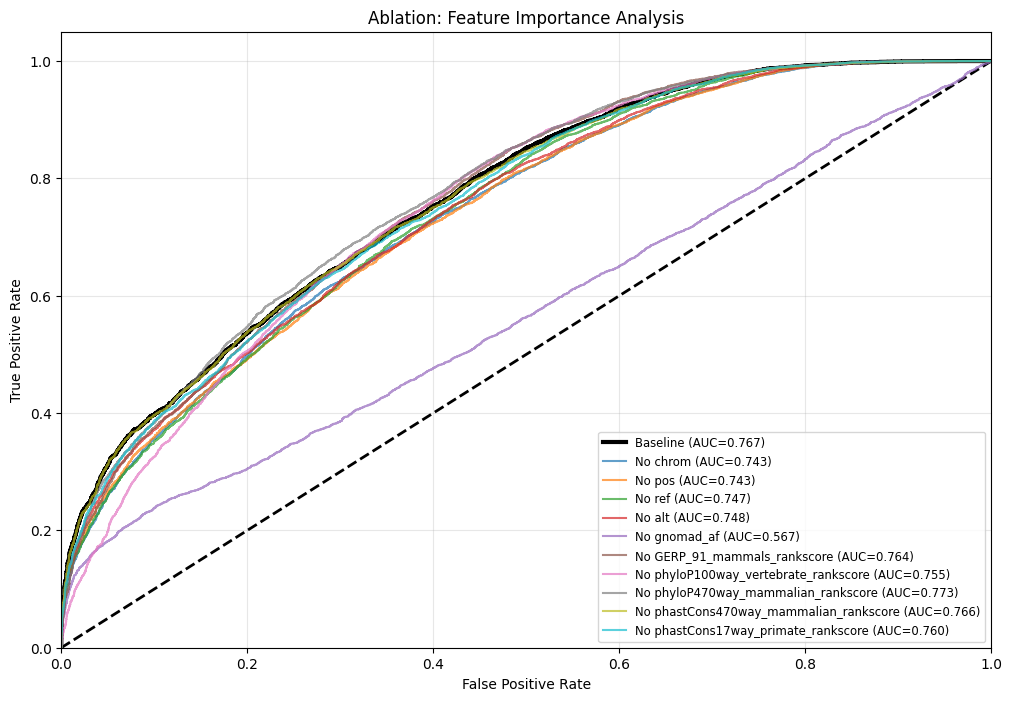

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("📉 Generating Ablation ROC Curves...")

plt.figure(figsize=(12, 8))

# baseline
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob)
plt.plot(fpr_base, tpr_base, lw=3, color='black',
         label=f'Baseline (AUC={base_auc:.3f})')

# random line
plt.plot([0,1], [0,1], 'k--', lw=2)

# store curves
curve_results = []

for feat in features:
    X_perm = X_test.copy()
    X_perm[feat] = np.random.permutation(X_perm[feat].values)

    # FIX TYPES AGAIN
    for col in ["chrom", "ref", "alt"]:
        if col in X_perm.columns:
            X_perm[col] = X_perm[col].astype("category")

    for col in X_perm.columns:
        if col not in ["chrom", "ref", "alt"]:
            X_perm[col] = pd.to_numeric(X_perm[col], errors="coerce")

    X_perm = X_perm.fillna(0)

    y_prob_perm = model.predict_proba(X_perm)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob_perm)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=1.5, alpha=0.7,
             label=f'No {feat} (AUC={roc_auc:.3f})')

# formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ablation: Feature Importance Analysis')
plt.legend(loc="lower right", fontsize='small')
plt.grid(True, alpha=0.3)

plt.savefig("ablation_roc.png", dpi=300)
plt.show()

In [22]:
print("\n🧪 Running NOISE-REMOVAL ABLATION (FINAL FIX)...")

# ---- DEFINE NOISY FEATURES ----
noise_features = [
    "GERP++_RS_rankscore",
    "phyloP17way_primate_rankscore",
    "phastCons100way_vertebrate_rankscore"
]

print(f"Removing {len(noise_features)} noisy features:")
print(noise_features)

# ---- START FROM ORIGINAL TEST ----
X_clean = X_test.copy()

# ---- 🔥 ZERO OUT (DO NOT DROP) ----
for f in noise_features:
    if f in X_clean.columns:
        X_clean[f] = 0.0

# ---- 🔥 FORCE EXACT TRAINING ORDER (CRITICAL) ----
feature_order = model.get_booster().feature_names
X_clean = X_clean[feature_order]

# ---- FIX TYPES ----
cat_cols = ["chrom", "ref", "alt"]

for col in cat_cols:
    if col in X_clean.columns:
        X_clean[col] = X_clean[col].astype("category")

for col in X_clean.columns:
    if col not in cat_cols:
        X_clean[col] = pd.to_numeric(X_clean[col], errors="coerce")

X_clean = X_clean.fillna(0)

# ---- PREDICT ----
y_prob_clean = model.predict_proba(X_clean)[:, 1]

# ---- METRICS ----
clean_auc = roc_auc_score(y_test, y_prob_clean)
clean_pr  = average_precision_score(y_test, y_prob_clean)

print("\n==========================================")
print("🧹 NOISE-REMOVED MODEL PERFORMANCE")
print("==========================================")
print(f"AUC     : {clean_auc:.6f}")
print(f"PR-AUC  : {clean_pr:.6f}")
print(f"AUC Gain: {clean_auc - base_auc:.6f}")
print(f"PR Gain : {clean_pr - base_pr:.6f}")


🧪 Running NOISE-REMOVAL ABLATION (FINAL FIX)...
Removing 3 noisy features:
['GERP++_RS_rankscore', 'phyloP17way_primate_rankscore', 'phastCons100way_vertebrate_rankscore']

🧹 NOISE-REMOVED MODEL PERFORMANCE
AUC     : 0.766809
PR-AUC  : 0.771672
AUC Gain: 0.000000
PR Gain : 0.000000


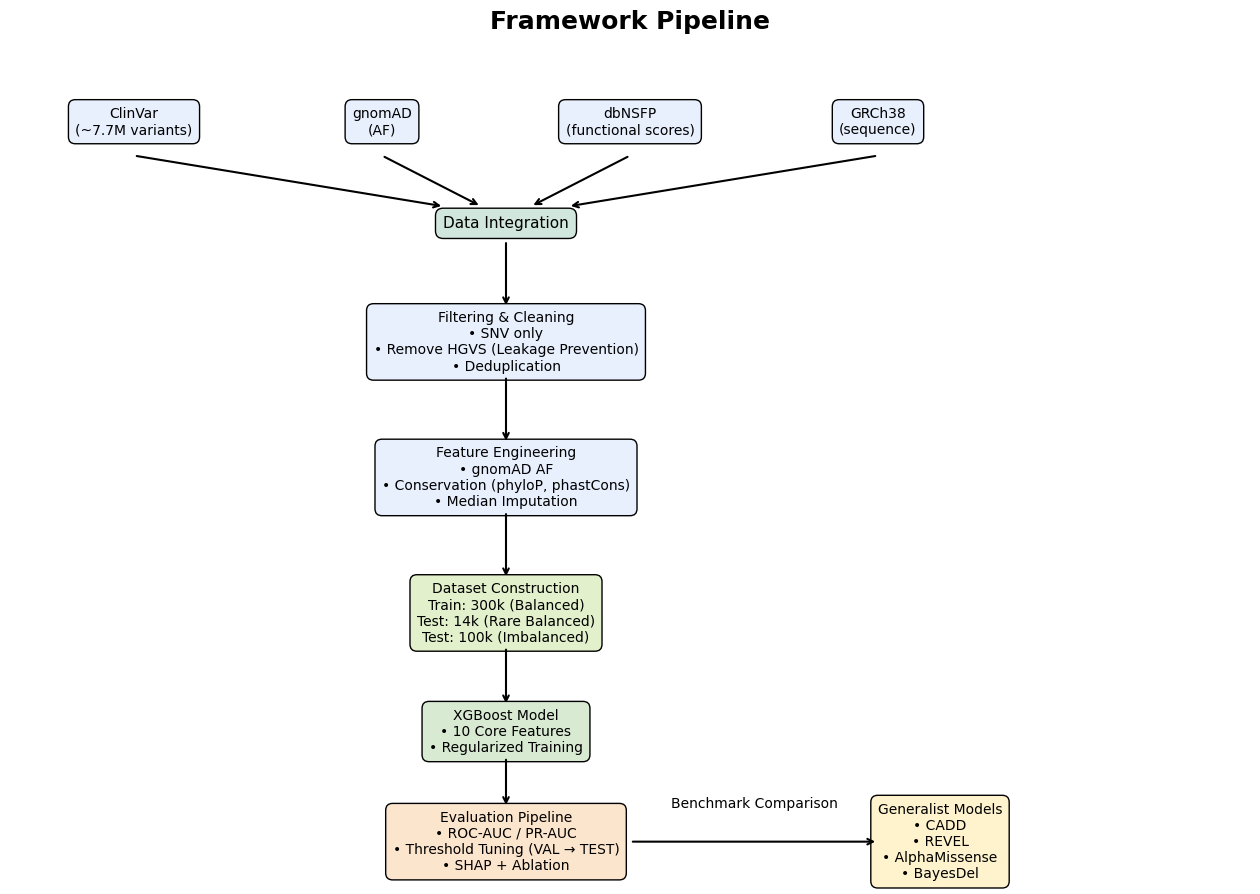

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 11))
ax.axis('off')

# ---------- Helper Functions ----------
def draw_box(text, xy, fc="#E8F0FE", size=10):
    ax.text(
        xy[0], xy[1], text,
        ha='center', va='center',
        fontsize=size,
        bbox=dict(boxstyle="round,pad=0.5", facecolor=fc, edgecolor='black')
    )

def draw_arrow(start, end):
    ax.annotate(
        "", xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

# ---------- TITLE ----------
plt.title("Framework Pipeline", fontsize=18, weight='bold')

# =====================================================
# DATA SOURCES (STRAIGHT + CLEAN)
# =====================================================
draw_box("ClinVar\n(~7.7M variants)", (0.1, 0.90))
draw_box("gnomAD\n(AF)", (0.3, 0.90))
draw_box("dbNSFP\n(functional scores)", (0.5, 0.90))
draw_box("GRCh38\n(sequence)", (0.7, 0.90))

draw_box("Data Integration", (0.4, 0.78), fc="#D1E7DD", size=11)

# straight arrows
draw_arrow((0.1, 0.86), (0.35, 0.80))
draw_arrow((0.3, 0.86), (0.38, 0.80))
draw_arrow((0.5, 0.86), (0.42, 0.80))
draw_arrow((0.7, 0.86), (0.45, 0.80))

# =====================================================
# PIPELINE (MORE SPACING)
# =====================================================
draw_box(
    "Filtering & Cleaning\n"
    "• SNV only\n"
    "• Remove HGVS (Leakage Prevention)\n"
    "• Deduplication",
    (0.4, 0.64),
)

draw_box(
    "Feature Engineering\n"
    "• gnomAD AF\n"
    "• Conservation (phyloP, phastCons)\n"
    "• Median Imputation",
    (0.4, 0.48),
)

draw_box(
    "Dataset Construction\n"
    "Train: 300k (Balanced)\n"
    "Test: 14k (Rare Balanced)\n"
    "Test: 100k (Imbalanced)",
    (0.4, 0.32),
    fc="#E2F0CB"
)

draw_box(
    "XGBoost Model\n"
    "• 10 Core Features\n"
    "• Regularized Training",
    (0.4, 0.18),
    fc="#D9EAD3"
)

draw_box(
    "Evaluation Pipeline\n"
    "• ROC-AUC / PR-AUC\n"
    "• Threshold Tuning (VAL → TEST)\n"
    "• SHAP + Ablation",
    (0.4, 0.05),
    fc="#FCE5CD"
)

# arrows (vertical clean)
draw_arrow((0.4, 0.76), (0.4, 0.68))
draw_arrow((0.4, 0.60), (0.4, 0.52))
draw_arrow((0.4, 0.44), (0.4, 0.36))
draw_arrow((0.4, 0.28), (0.4, 0.21))
draw_arrow((0.4, 0.15), (0.4, 0.09))

# =====================================================
# BENCHMARK (FIXED CLEANLY)
# =====================================================
draw_box(
    "Generalist Models\n"
    "• CADD\n• REVEL\n• AlphaMissense\n• BayesDel",
    (0.75, 0.05),
    fc="#FFF3CD"
)

# clean horizontal arrow
draw_arrow((0.50, 0.05), (0.70, 0.05))

# aligned label
ax.text(0.60, 0.09, "Benchmark Comparison", fontsize=10, ha='center')

# =====================================================
# SAVE
# =====================================================
# plt.savefig("framework_final.svg", bbox_inches='tight')
# plt.savefig("framework_final.png", dpi=300, bbox_inches='tight')

plt.show()